In [63]:
!pip install -U nbformat


   ---------------------------------------- 0/2 [fastjsonschema]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   -------------------- ------------------- 1/2 [nbformat]
   ---------------------------------------- 2/2 [nbformat]



In [1]:
1250080179 % 31

2

In [69]:
!pip install pyvi

  Using cached pyvi-0.1.1-py2.py3-none-any.whl.metadata (2.5 kB)
Using cached pyvi-0.1.1-py2.py3-none-any.whl (8.5 MB)


# Clustering

In [3]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import MeanShift, KMeans
from sklearn.metrics import silhouette_score
from plotly.express import scatter_3d
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler, MaxAbsScaler, RobustScaler, LabelBinarizer
from pyvi.ViTokenizer import tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, classification_report

d:\Python\Lib\site-packages\pyvi\ViTokenizer.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  model = pickle.load(fin)


In [4]:
X = [
    [0, 0],
    [0, 1],
    [1, 0],
    [7, 0],
    [0, 7],
    [5, 5]
]
lk = linkage(X, method = 'average')
lk

array([[0.        , 1.        , 1.        , 2.        ],
       [2.        , 6.        , 1.20710678, 3.        ],
       [3.        , 5.        , 5.38516481, 2.        ],
       [7.        , 8.        , 6.65806402, 5.        ],
       [4.        , 9.        , 7.07114551, 6.        ]])

# 0 => A, 1 => B, 2 => C, 3 => D, 4 => E, 5 => F, 6 => AB, 7 => ABC, 8 => EF, 9 => 

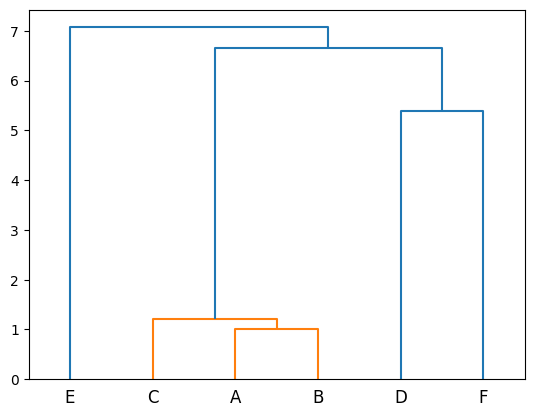

In [5]:
dendrogram(lk, labels=['A', 'B', 'C', 'D', 'E', 'F'])
plt.show()

In [6]:
ac = AgglomerativeClustering(n_clusters=2, linkage='average')
ac.fit(X)
ac.labels_

array([0, 0, 0, 0, 1, 0])

In [7]:
ac = AgglomerativeClustering(n_clusters=3, linkage='average')
ac.fit(X)
ac.labels_

array([2, 2, 2, 0, 1, 0])

In [8]:
ac = AgglomerativeClustering(n_clusters=4, linkage='average')
ac.fit(X)
ac.labels_

array([0, 0, 0, 3, 1, 2])

## Load data from csv

In [9]:
df = pd.read_csv('data/Mall_Customers.csv')
df.head(n=2)

,CustomerID,Gender,Age,AnnualIncome(k$),SpendingScore(1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81


## Check null

In [10]:
df.isna().sum()

CustomerID              0
Gender                  0
Age                     0
AnnualIncome(k$)        0
SpendingScore(1-100)    0
dtype: int64

# Preprocessing Binary

In [11]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [12]:
encoder = LabelEncoder()
df['Gender'] = encoder.fit_transform(df['Gender'])
df.head(n=2)

,CustomerID,Gender,Age,AnnualIncome(k$),SpendingScore(1-100)
0,1,1,19,15,39
1,2,1,21,15,81


## Drop column Customer

In [13]:
df.drop(columns='CustomerID', inplace=True)
df.head(n=2)

,Gender,Age,AnnualIncome(k$),SpendingScore(1-100)
0,1,19,15,39
1,1,21,15,81


## EDA

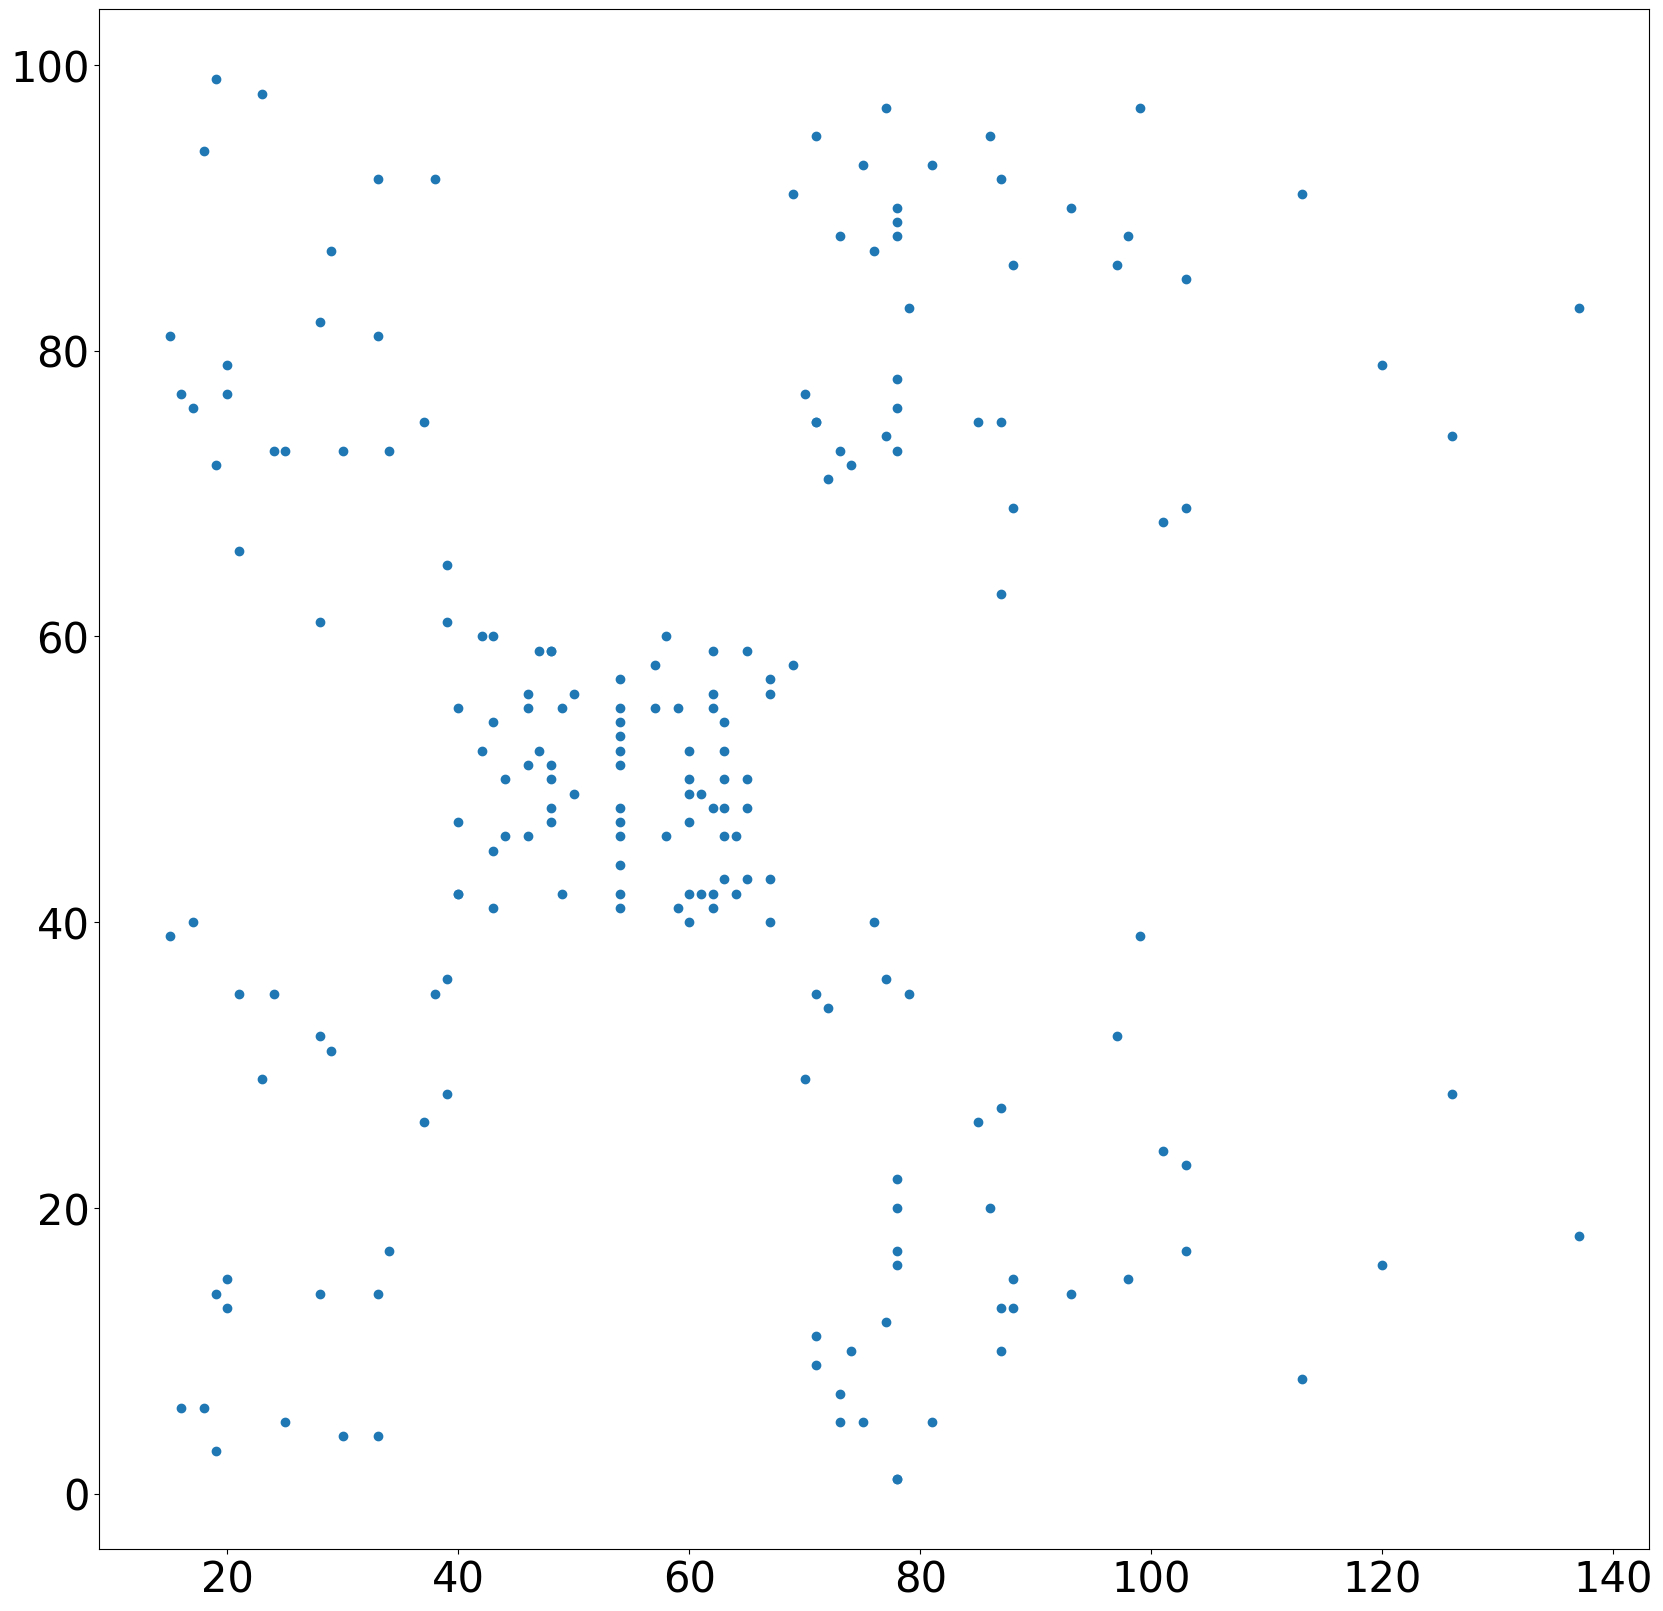

In [14]:
plt.rcParams['figure.figsize'] =(20, 20)
plt.rcParams['font.size'] = 30
plt.scatter(x= df['AnnualIncome(k$)'], y = df['SpendingScore(1-100)'])
plt.show()

In [15]:
np.linspace(0.5, 1, 20)

array([0.5       , 0.52631579, 0.55263158, 0.57894737, 0.60526316,
       0.63157895, 0.65789474, 0.68421053, 0.71052632, 0.73684211,
       0.76315789, 0.78947368, 0.81578947, 0.84210526, 0.86842105,
       0.89473684, 0.92105263, 0.94736842, 0.97368421, 1.        ])

In [16]:
for bw in np.linspace(15, 30, 20):
    ms = MeanShift(bandwidth=bw)
    X = df[['AnnualIncome(k$)', 'SpendingScore(1-100)']]
    ms.fit(X)
    print(bw, np.unique(ms.labels_))

15.0 [0 1 2 3 4 5 6 7]
15.789473684210526 [0 1 2 3 4 5 6 7 8]
16.57894736842105 [0 1 2 3 4 5 6]
17.36842105263158 [0 1 2 3 4 5 6 7]
18.157894736842106 [0 1 2 3 4 5 6]
18.94736842105263 [0 1 2 3 4 5 6]
19.736842105263158 [0 1 2 3 4 5 6]
20.526315789473685 [0 1 2 3 4 5 6]
21.315789473684212 [0 1 2 3 4 5]
22.105263157894736 [0 1 2 3 4]
22.894736842105264 [0 1 2 3 4]
23.684210526315788 [0 1 2 3 4]
24.473684210526315 [0 1 2 3 4]
25.263157894736842 [0 1 2 3 4]
26.05263157894737 [0 1 2 3]
26.842105263157897 [0 1 2]
27.63157894736842 [0 1 2]
28.421052631578945 [0 1]
29.210526315789473 [0 1]
30.0 [0]


In [17]:
ms = MeanShift(bandwidth=25)
ms.fit(X)
df['Mean Shift Cluster'] = ms.labels_
df.head()

,Gender,Age,AnnualIncome(k$),SpendingScore(1-100),Mean Shift Cluster
0,1,19,15,39,4
1,1,21,15,81,3
2,0,20,16,6,4
3,0,23,16,77,3
4,0,31,17,40,4


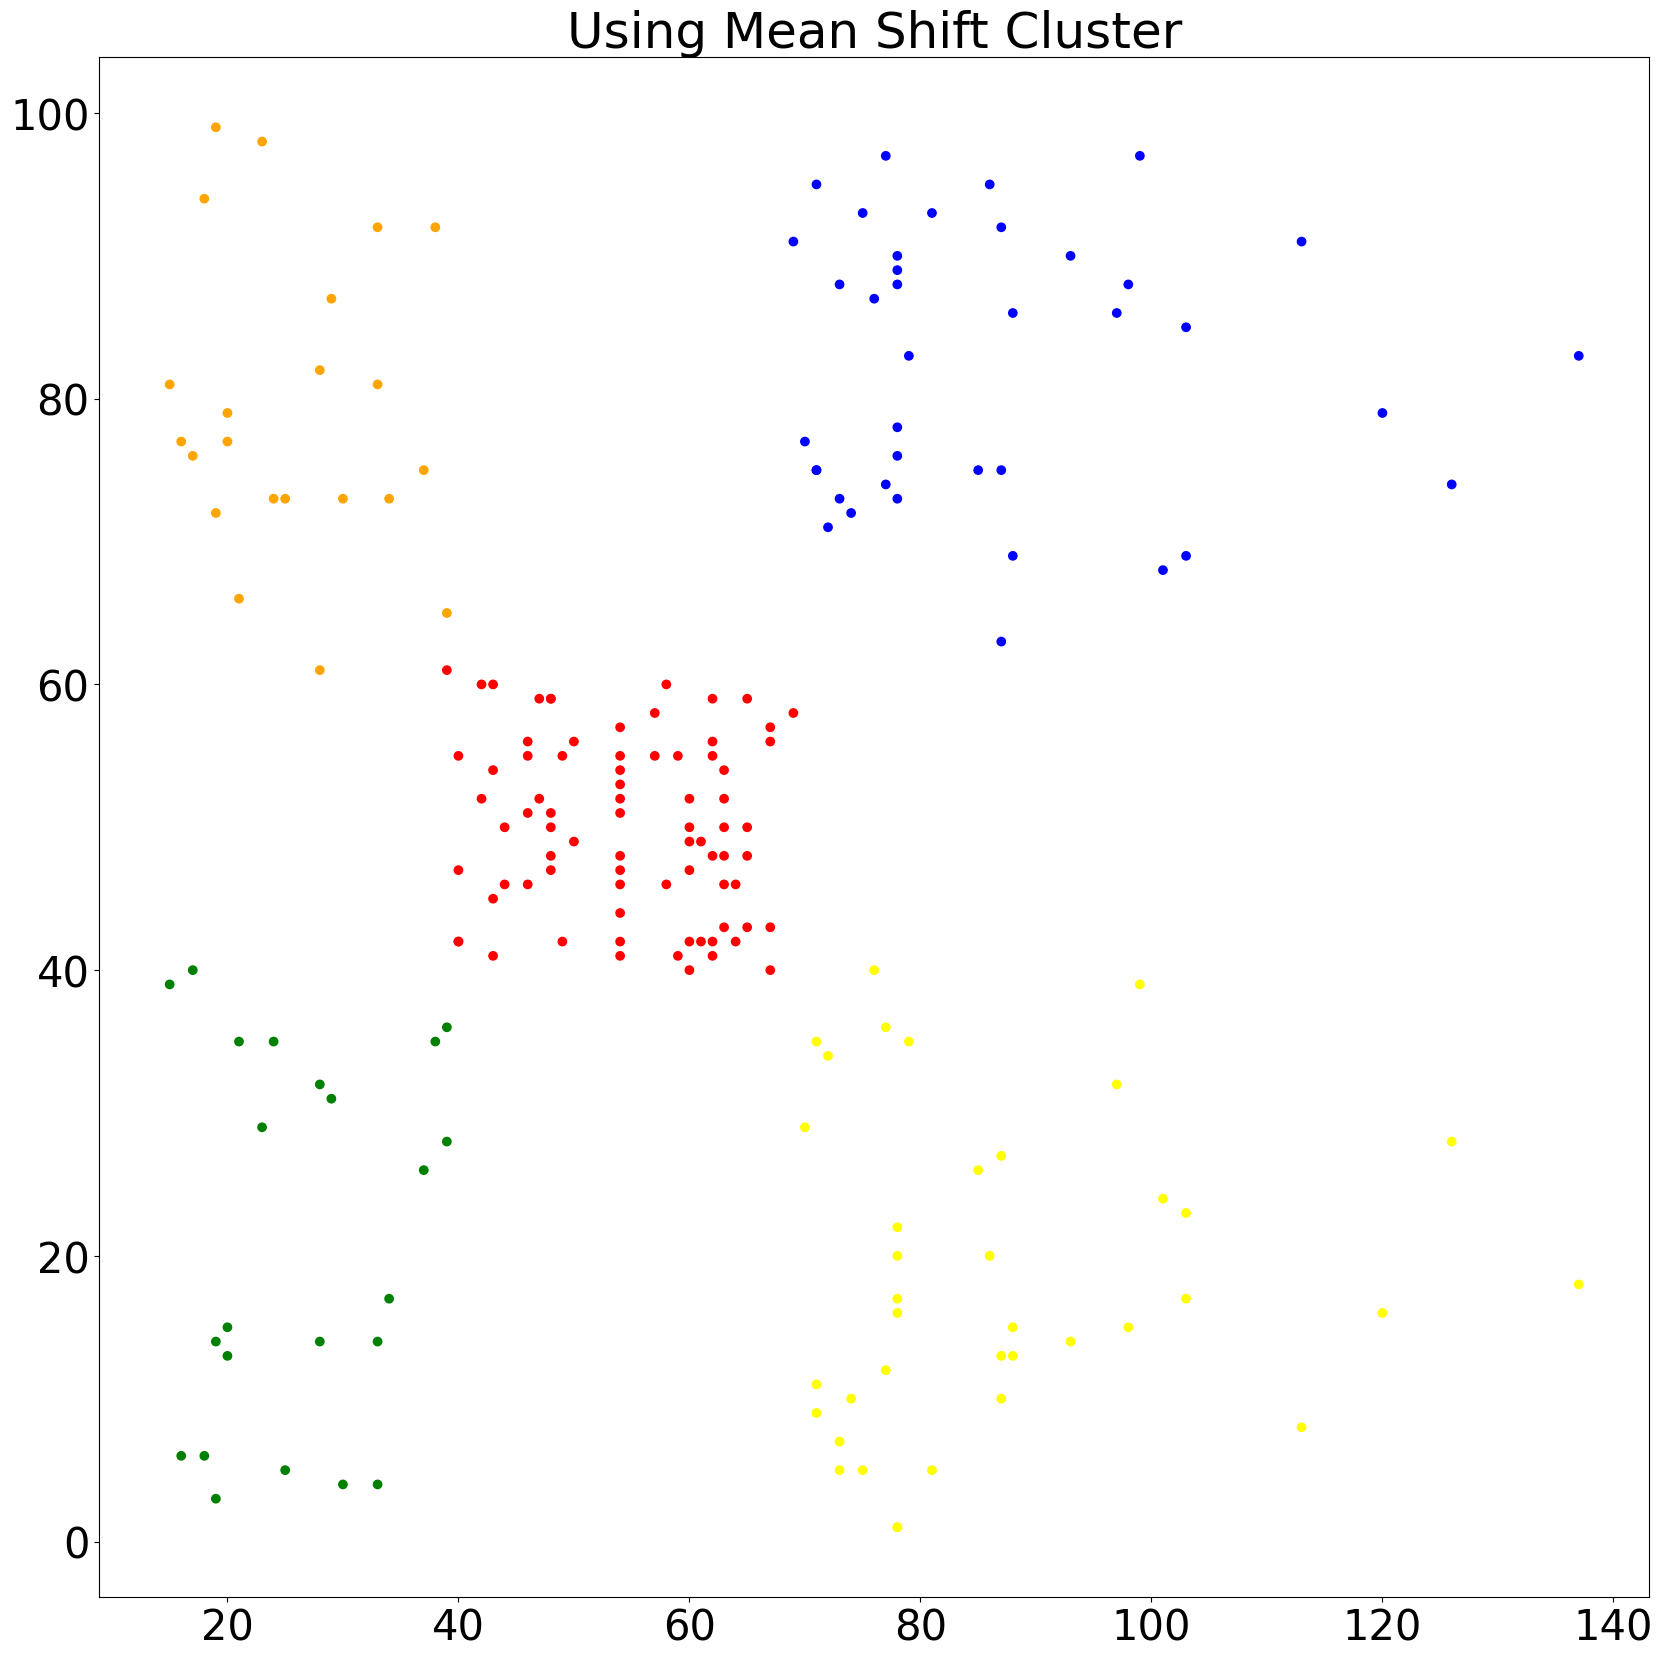

In [18]:
colors = ['red', 'blue', 'yellow', 'orange', 'green']
plt.rcParams['figure.figsize'] = (20, 20)
plt.rcParams['font.size'] = 30
plt.scatter(x=df['AnnualIncome(k$)'], y=df['SpendingScore(1-100)'], c=[colors[v] for v in df['Mean Shift Cluster']])
plt.title('Using Mean Shift Cluster')
plt.show()

## Find k cluster optimizer

In [19]:
bandwidths = [29, 27, 26, 25, 21, 16]
scores = []
for bw in bandwidths:
    ms = MeanShift(bandwidth=bw)
    ms.fit(X)
    # print(bw, np.unique(ms.labels_))
    scores.append(silhouette_score(X, ms.labels_))
scores

[0.39341241439002433,
 0.4649831662238108,
 0.49013162285715894,
 0.5513250428036421,
 0.5126972460016974,
 0.5155587965871535]

In [20]:
np.argmax(scores) + 2

np.int64(5)

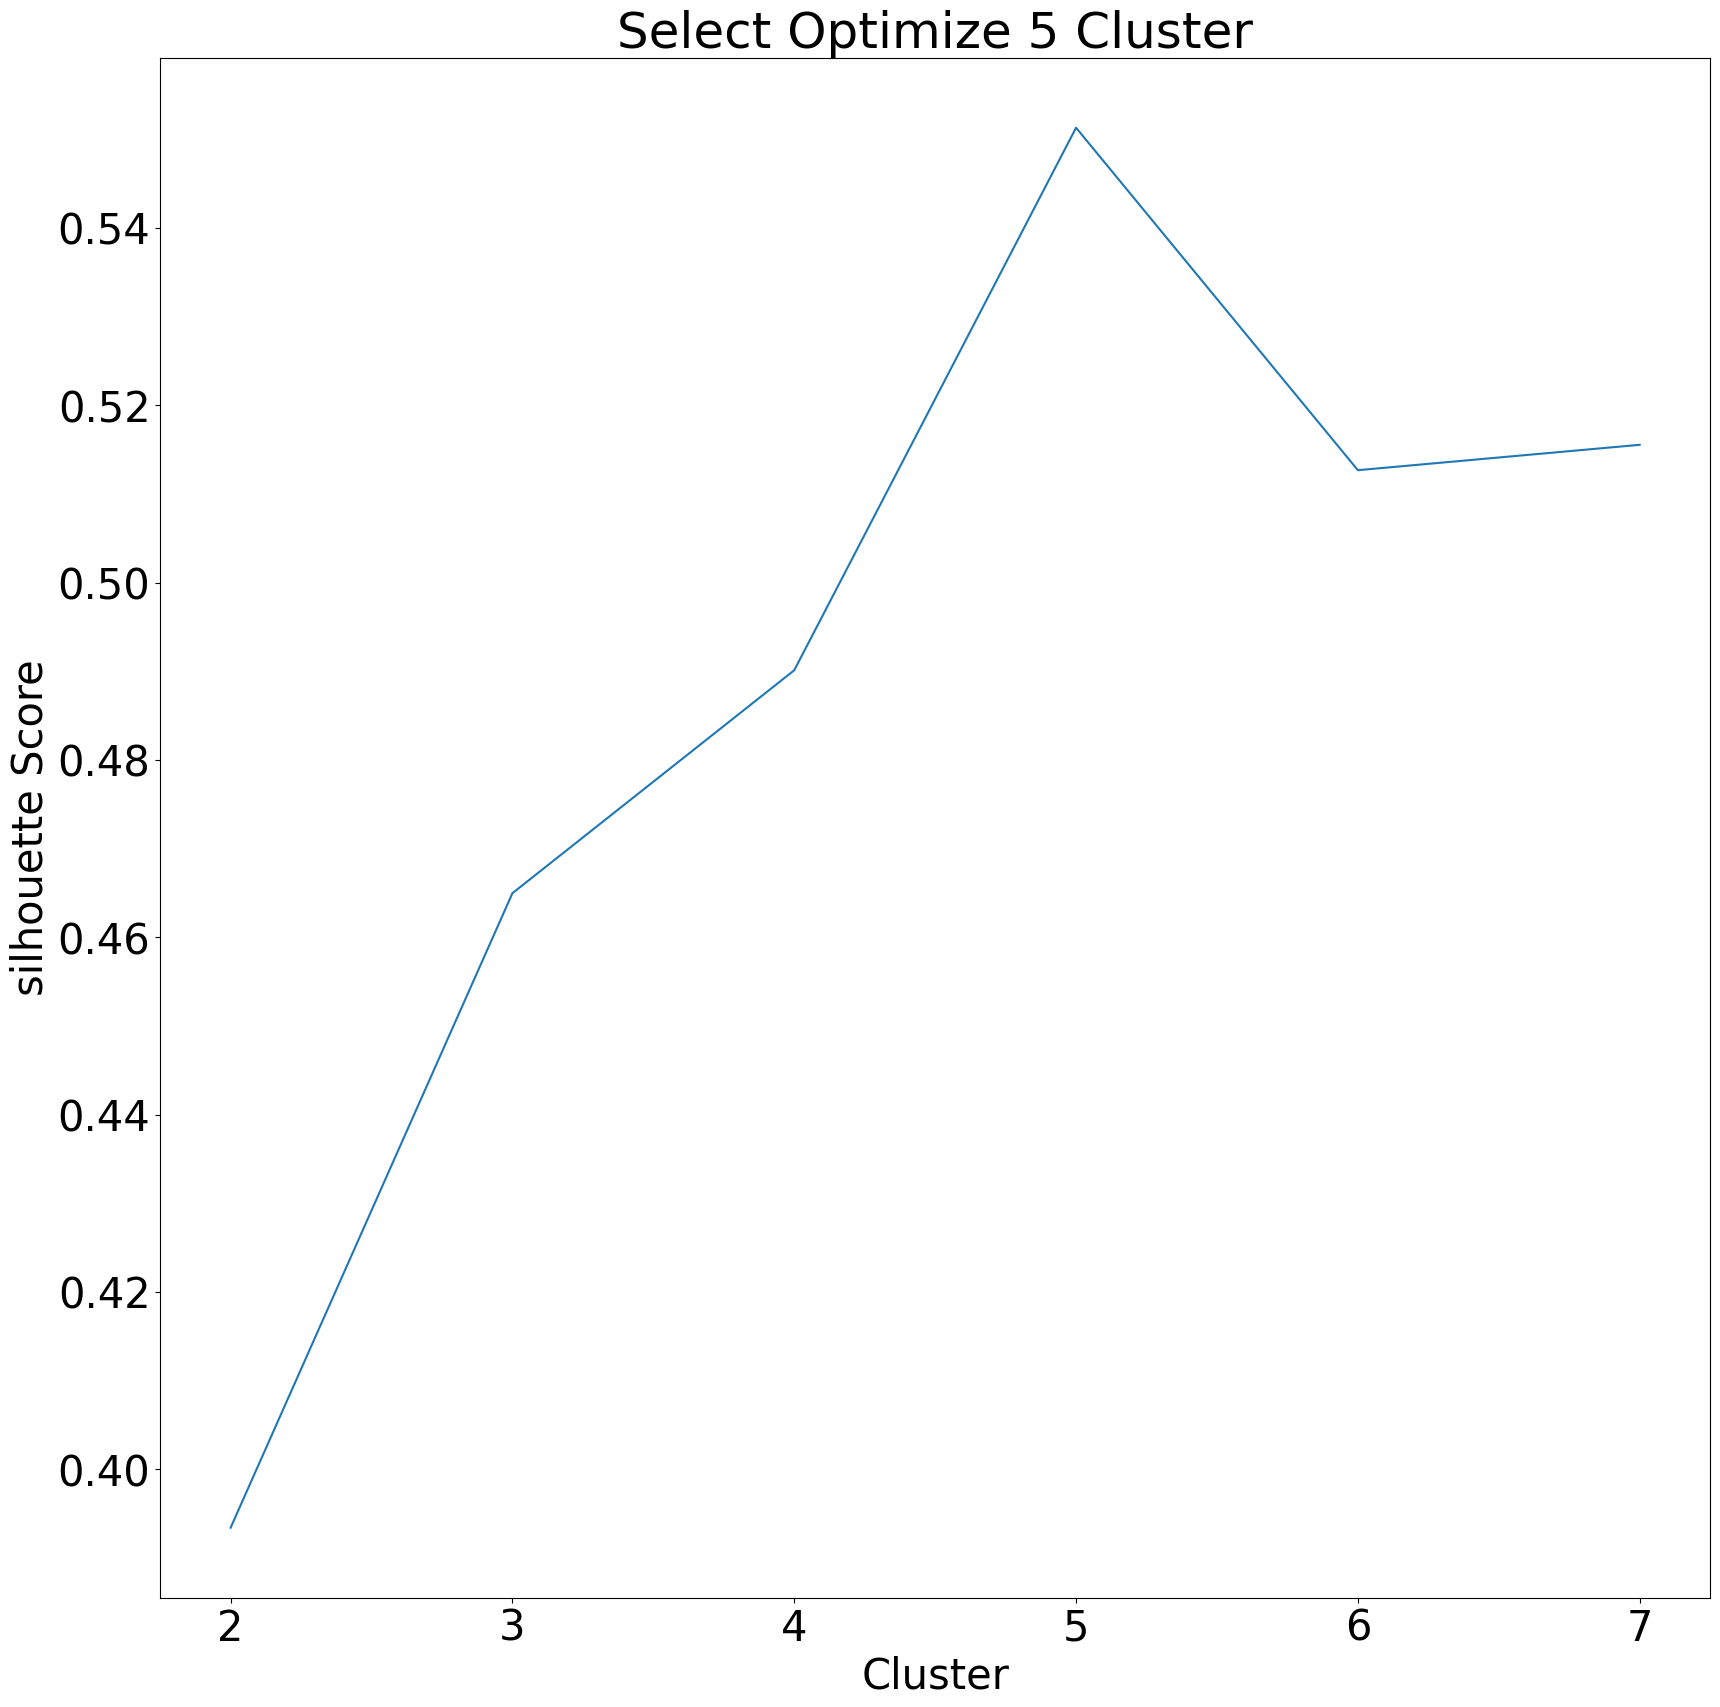

In [21]:
plt.plot(range(2,8), scores)
plt.xlabel('Cluster')
plt.ylabel('silhouette Score')
plt.title(f'Select Optimize {np.argmax(scores)+ 2} Cluster')
plt.show()

In [22]:
df.columns

Index(['Gender', 'Age', 'AnnualIncome(k$)', 'SpendingScore(1-100)',
       'Mean Shift Cluster'],
      dtype='object')

## Age vs Annual Income vs Spending Score

In [23]:
scatter_3d(data_frame=df, x = 'AnnualIncome(k$)', y ='SpendingScore(1-100)', z = 'Age')

In [24]:
X = df[['Age', 'AnnualIncome(k$)', 'SpendingScore(1-100)']]
ms = MeanShift(bandwidth=25)
ms.fit(X)
# np.unique(ms.labels_)
df['Mean Shift Cluster With Age'] = ms.labels_

In [25]:
scatter_3d(data_frame=df, x = 'AnnualIncome(k$)', y ='SpendingScore(1-100)', z = 'Age', color=[colors[v] for v in df['Mean Shift Cluster With Age']])

## Age vs Annual Income vs Gender

In [26]:
X = df[['Gender', 'AnnualIncome(k$)', 'SpendingScore(1-100)']]
ms = MeanShift(bandwidth=25)
ms.fit(X)
# np.unique(ms.labels_)
df['Mean Shift Cluster With Gender'] = ms.labels_

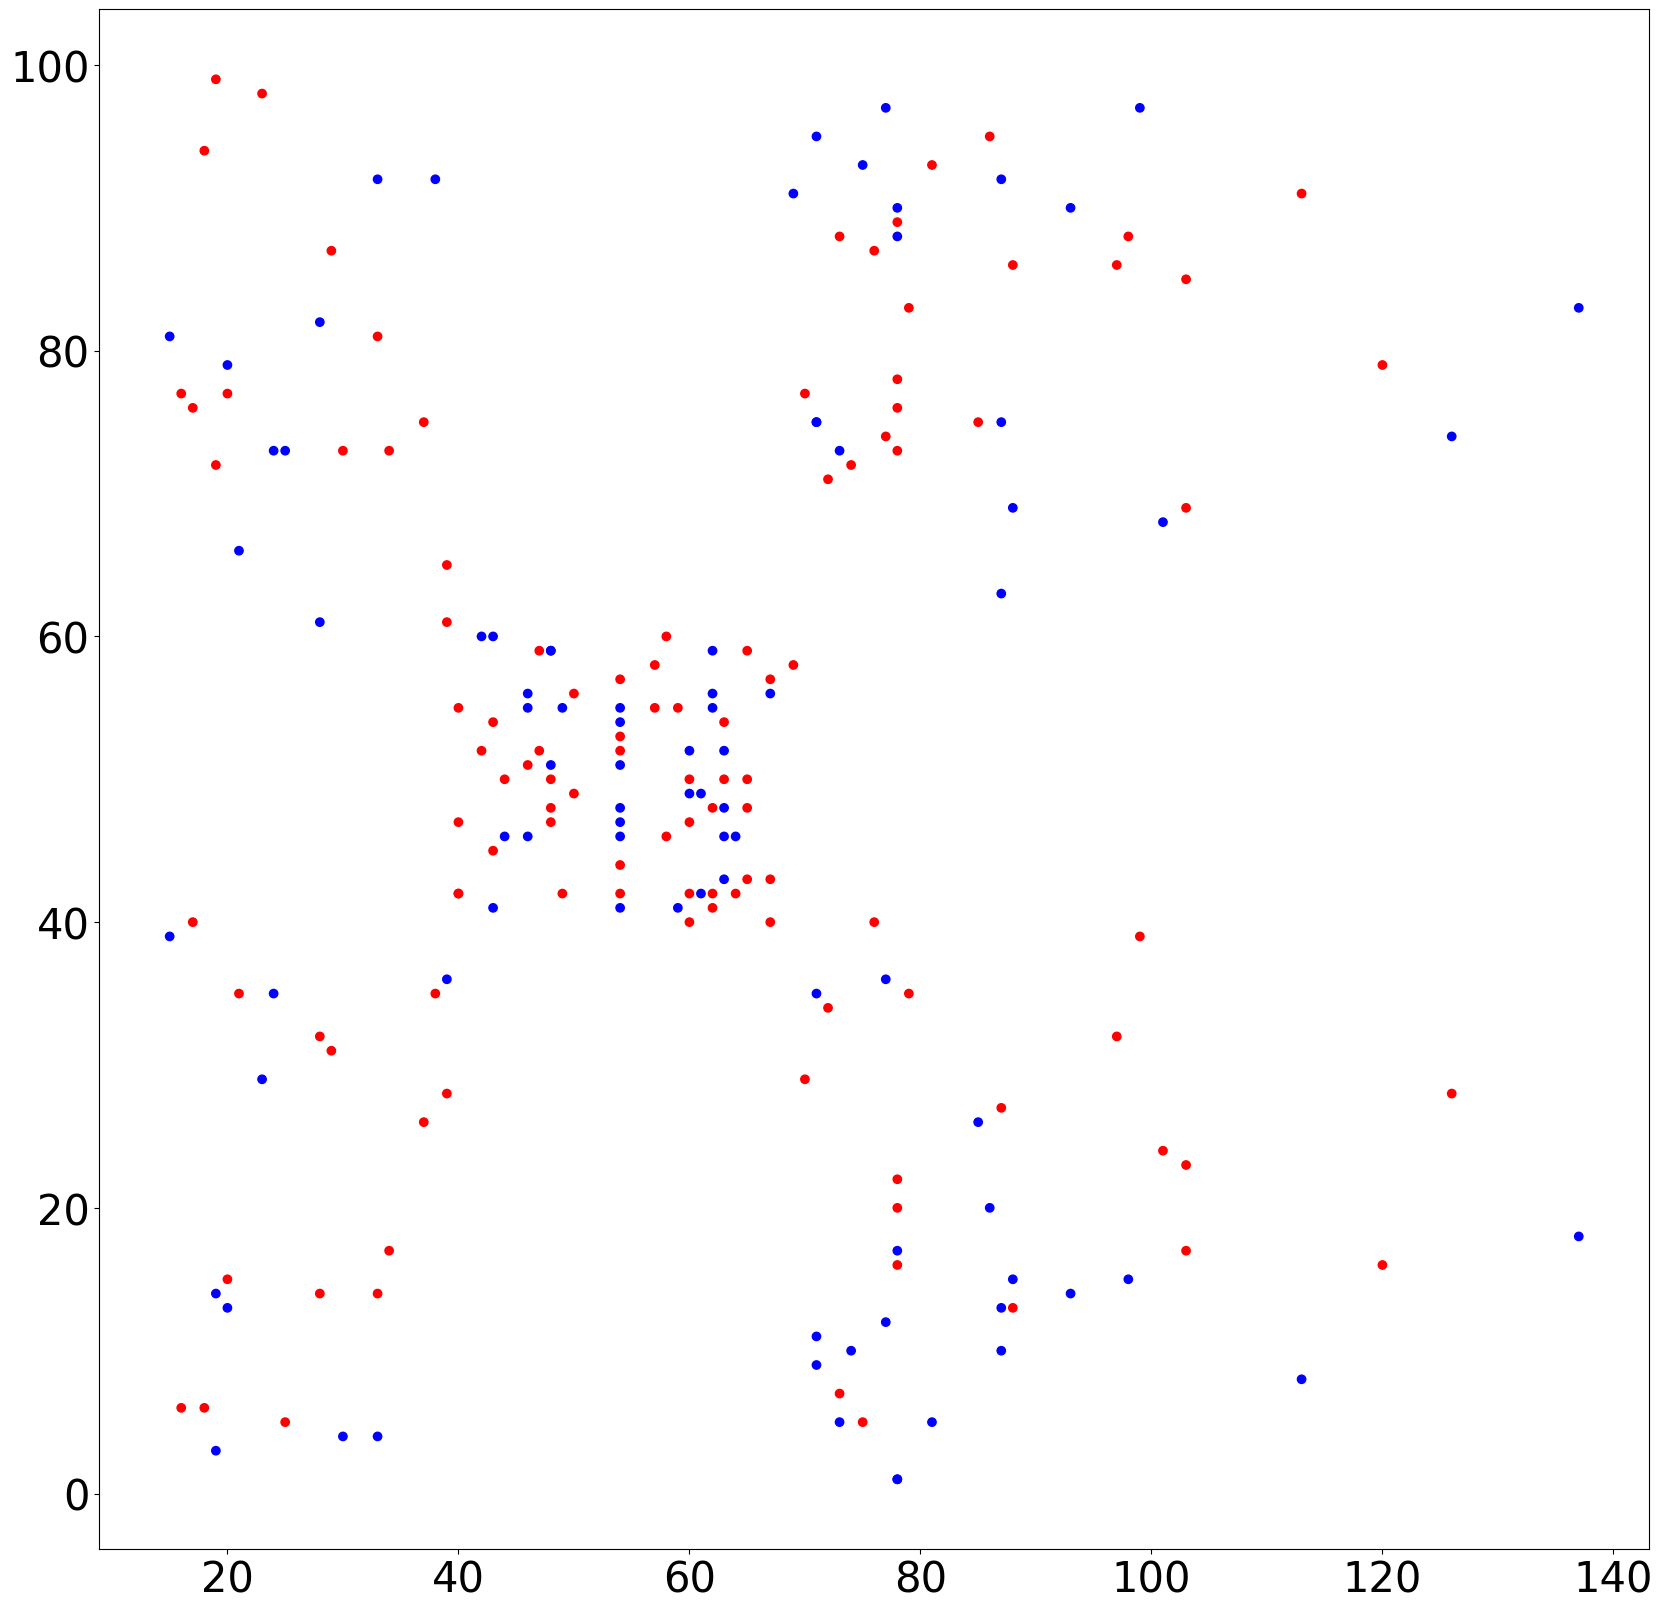

In [27]:
genders = ['red', 'blue']
plt.scatter(x = df['AnnualIncome(k$)'], y = df['SpendingScore(1-100)'], c = [genders[v] for v in df['Gender']])
plt.show()

In [28]:
df.columns

Index(['Gender', 'Age', 'AnnualIncome(k$)', 'SpendingScore(1-100)',
       'Mean Shift Cluster', 'Mean Shift Cluster With Age',
       'Mean Shift Cluster With Gender'],
      dtype='object')

In [29]:
dic = {
    'Mean Shift Cluster': df[['AnnualIncome(k$)', 'SpendingScore(1-100)']],
    'Mean Shift Cluster With Age': df[['AnnualIncome(k$)', 'SpendingScore(1-100)', 'Age']],
    'Mean Shift Cluster With Gender': df[['AnnualIncome(k$)', 'SpendingScore(1-100)', 'Gender']],
}
result = []
for name in dic:
    score = silhouette_score(dic[name], df[name])
    result.append({'Title': name, 'Silhouette Score': score})
pd.DataFrame(result)


,Title,Silhouette Score
0,Mean Shift Cluster,0.551325
1,Mean Shift Cluster With Age,0.443280
2,Mean Shift Cluster With Gender,0.550832


In [30]:
fig = scatter_3d(data_frame=df, x='AnnualIncome(k$)', y='SpendingScore(1-100)', z='Age',color=[colors[v] for v in df['Mean Shift Cluster With Age']])
fig.update_layout(width=1000, height=600)
fig.show()

In [31]:
df.describe()

,Gender,Age,AnnualIncome(k$),SpendingScore(1-100),Mean Shift Cluster,Mean Shift Cluster With Age,Mean Shift Cluster With Gender
count,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.00000
mean,0.440000,38.850000,60.560000,50.200000,1.36500,1.360000,1.36500
std,0.497633,13.969007,26.264721,25.823522,1.38976,1.396478,1.38976
min,0.000000,18.000000,15.000000,1.000000,0.00000,0.000000,0.00000
25%,0.000000,28.750000,41.500000,34.750000,0.00000,0.000000,0.00000
50%,0.000000,36.000000,61.500000,50.000000,1.00000,1.000000,1.00000
75%,1.000000,49.000000,78.000000,73.000000,2.00000,2.000000,2.00000
max,1.000000,70.000000,137.000000,99.000000,4.00000,4.000000,4.00000


In [32]:
df[['Gender', 'Age', 'AnnualIncome(k$)', 'SpendingScore(1-100)']].describe()

,Gender,Age,AnnualIncome(k$),SpendingScore(1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,0.440000,38.850000,60.560000,50.200000
std,0.497633,13.969007,26.264721,25.823522
min,0.000000,18.000000,15.000000,1.000000
25%,0.000000,28.750000,41.500000,34.750000
50%,0.000000,36.000000,61.500000,50.000000
75%,1.000000,49.000000,78.000000,73.000000
max,1.000000,70.000000,137.000000,99.000000


In [33]:
df.columns

Index(['Gender', 'Age', 'AnnualIncome(k$)', 'SpendingScore(1-100)',
       'Mean Shift Cluster', 'Mean Shift Cluster With Age',
       'Mean Shift Cluster With Gender'],
      dtype='object')

## Preprocessing Standard Scale

In [34]:
cols_cont = ['Age', 'AnnualIncome(k$)', 'SpendingScore(1-100)']
standard = StandardScaler()
df[['AgeScale', 'AnnualIncomeScale', 'SpendingScoreScale']] = standard.fit_transform(df[cols_cont])

In [35]:
X = df[['AnnualIncomeScale', 'SpendingScoreScale']]
for bw in np.linspace(0.5, 1, 10):
    ms = MeanShift(bandwidth=bw)
    ms.fit(X)
    print(bw, np.unique(ms.labels_))

0.5 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
0.5555555555555556 [0 1 2 3 4 5 6 7 8 9]
0.6111111111111112 [0 1 2 3 4 5 6 7 8]
0.6666666666666666 [0 1 2 3 4 5 6]
0.7222222222222222 [0 1 2 3 4 5 6]
0.7777777777777778 [0 1 2 3 4 5 6]
0.8333333333333333 [0 1 2 3 4]
0.8888888888888888 [0 1 2 3 4]
0.9444444444444444 [0 1 2 3 4]
1.0 [0 1 2 3]


In [36]:
ms = MeanShift(bandwidth=0.85)
X = df[['AnnualIncomeScale', 'SpendingScoreScale']]
ms.fit(X)
df['Mean Shift Cluster Scale'] = ms.labels_

In [37]:
X = df[['AnnualIncomeScale', 'SpendingScoreScale', 'AgeScale']]

for bw in np.linspace(0.8, 1.5, 10):
    ms = MeanShift(bandwidth=bw)
    ms.fit(X)
    print(bw, np.unique(ms.labels_))

0.8 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
0.8777777777777778 [ 0  1  2  3  4  5  6  7  8  9 10 11]
0.9555555555555556 [0 1 2 3 4 5 6 7 8 9]
1.0333333333333334 [0 1 2 3 4 5 6]
1.1111111111111112 [0 1 2 3 4]
1.1888888888888889 [0 1 2 3]
1.2666666666666666 [0 1 2 3]
1.3444444444444446 [0 1 2]
1.4222222222222223 [0]
1.5 [0]


In [38]:
ms = MeanShift(bandwidth=1.1)
X = df[['AnnualIncomeScale', 'SpendingScoreScale', 'AgeScale']]
ms.fit(X)
#print(np.unique(ms.labels_))
df['Mean Shift Cluster With Age Scale'] = ms.labels_

In [39]:
ms = MeanShift(bandwidth=1.1)
X = df[['AnnualIncomeScale', 'SpendingScoreScale', 'Gender']]
ms.fit(X)
#print(np.unique(ms.labels_))
df['Mean Shift Cluster With Gender Scale'] = ms.labels_

In [40]:
dic = {
    'Mean Shift Cluster Scale': df[['AnnualIncomeScale', 'SpendingScoreScale']],
    'Mean Shift Cluster With Age Scale': df[['AnnualIncomeScale', 'SpendingScoreScale', 'AgeScale']],
    'Mean Shift Cluster With Gender Scale': df[['AnnualIncomeScale', 'SpendingScoreScale', 'Gender']]
}
result = []
for name in dic:
    score = silhouette_score(dic[name], df[name])
    result.append({'Title': name, 'Silhouette Score': score})
pd.DataFrame(result)

,Title,Silhouette Score
0,Mean Shift Cluster Scale,0.549451
1,Mean Shift Cluster With Age Scale,0.405935
2,Mean Shift Cluster With Gender Scale,0.428396


## Mean Shift vs KMean vs AgglomerativeClustering

In [41]:
df.columns

Index(['Gender', 'Age', 'AnnualIncome(k$)', 'SpendingScore(1-100)',
       'Mean Shift Cluster', 'Mean Shift Cluster With Age',
       'Mean Shift Cluster With Gender', 'AgeScale', 'AnnualIncomeScale',
       'SpendingScoreScale', 'Mean Shift Cluster Scale',
       'Mean Shift Cluster With Age Scale',
       'Mean Shift Cluster With Gender Scale'],
      dtype='object')

In [42]:
X = df[['AnnualIncomeScale', 'SpendingScoreScale']]
models = {
    'Mean Shift': MeanShift(bandwidth=0.85),
    'K-Means': KMeans(n_clusters=5),
    'Agglomerative': AgglomerativeClustering(n_clusters=5)
}
result = []
for name in models:
    models[name].fit(X)
    result.append({
        'Model': name,
        'Silhouette Score': silhouette_score(X, models[name].labels_)
    })
pd.DataFrame(result)

,Model,Silhouette Score
0,Mean Shift,0.549451
1,K-Means,0.470337
2,Agglomerative,0.553809


### Hierachy Cluster

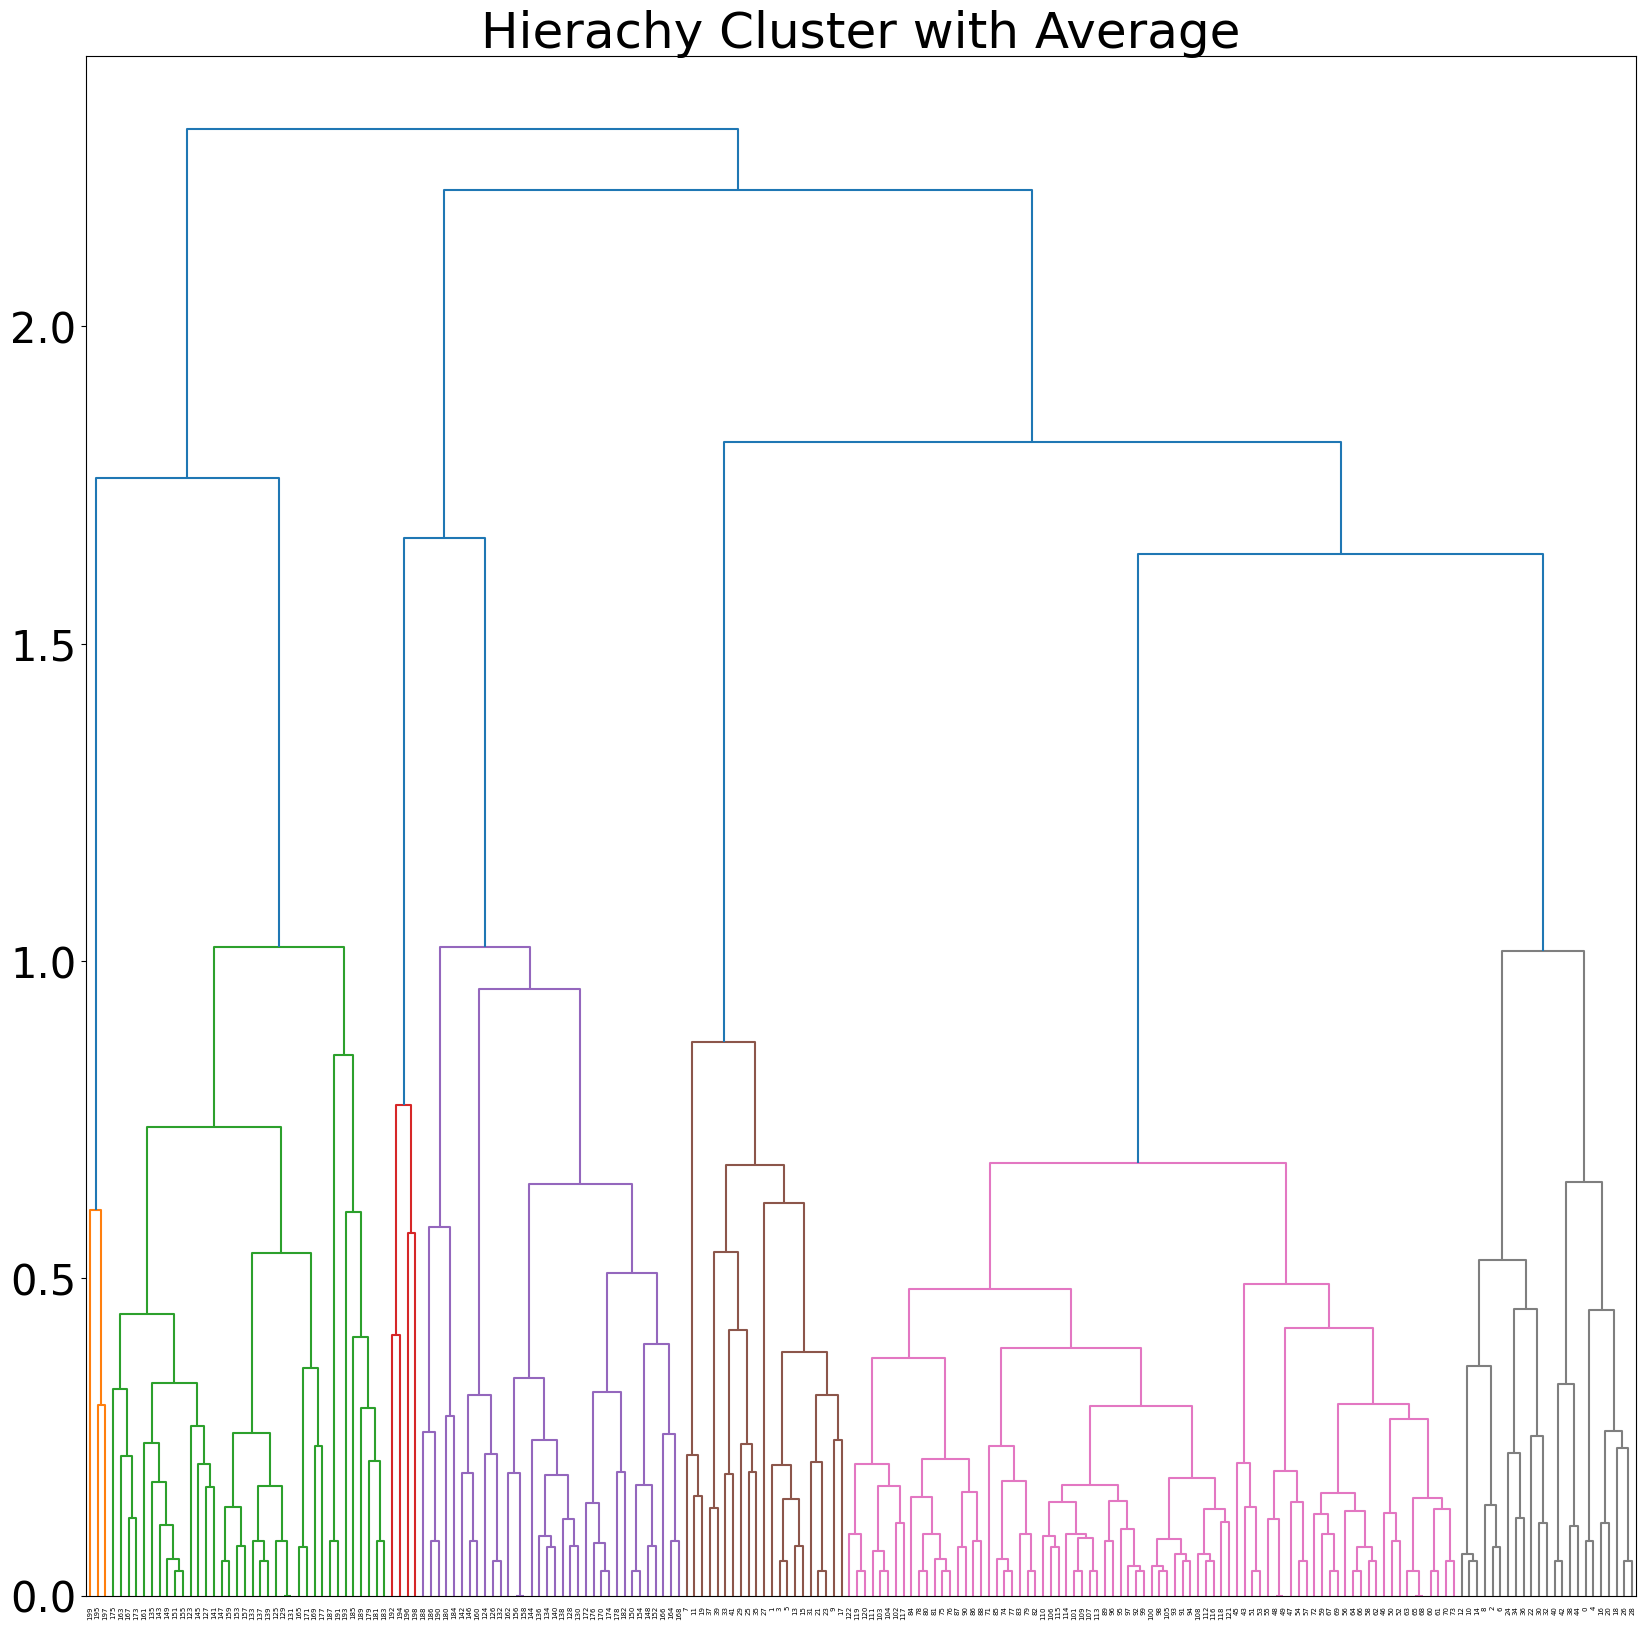

In [43]:
lk = linkage(X, method='average')
dendrogram(lk, p=5)
plt.title('Hierachy Cluster with Average')
plt.show()

### KMeans

In [44]:
scores = {'inertia': [], 'silhouette': []}
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    scores['inertia'].append(kmeans.inertia_)
    scores['silhouette'].append(silhouette_score(X, kmeans.labels_))

### Ebow method vs Silhouette score

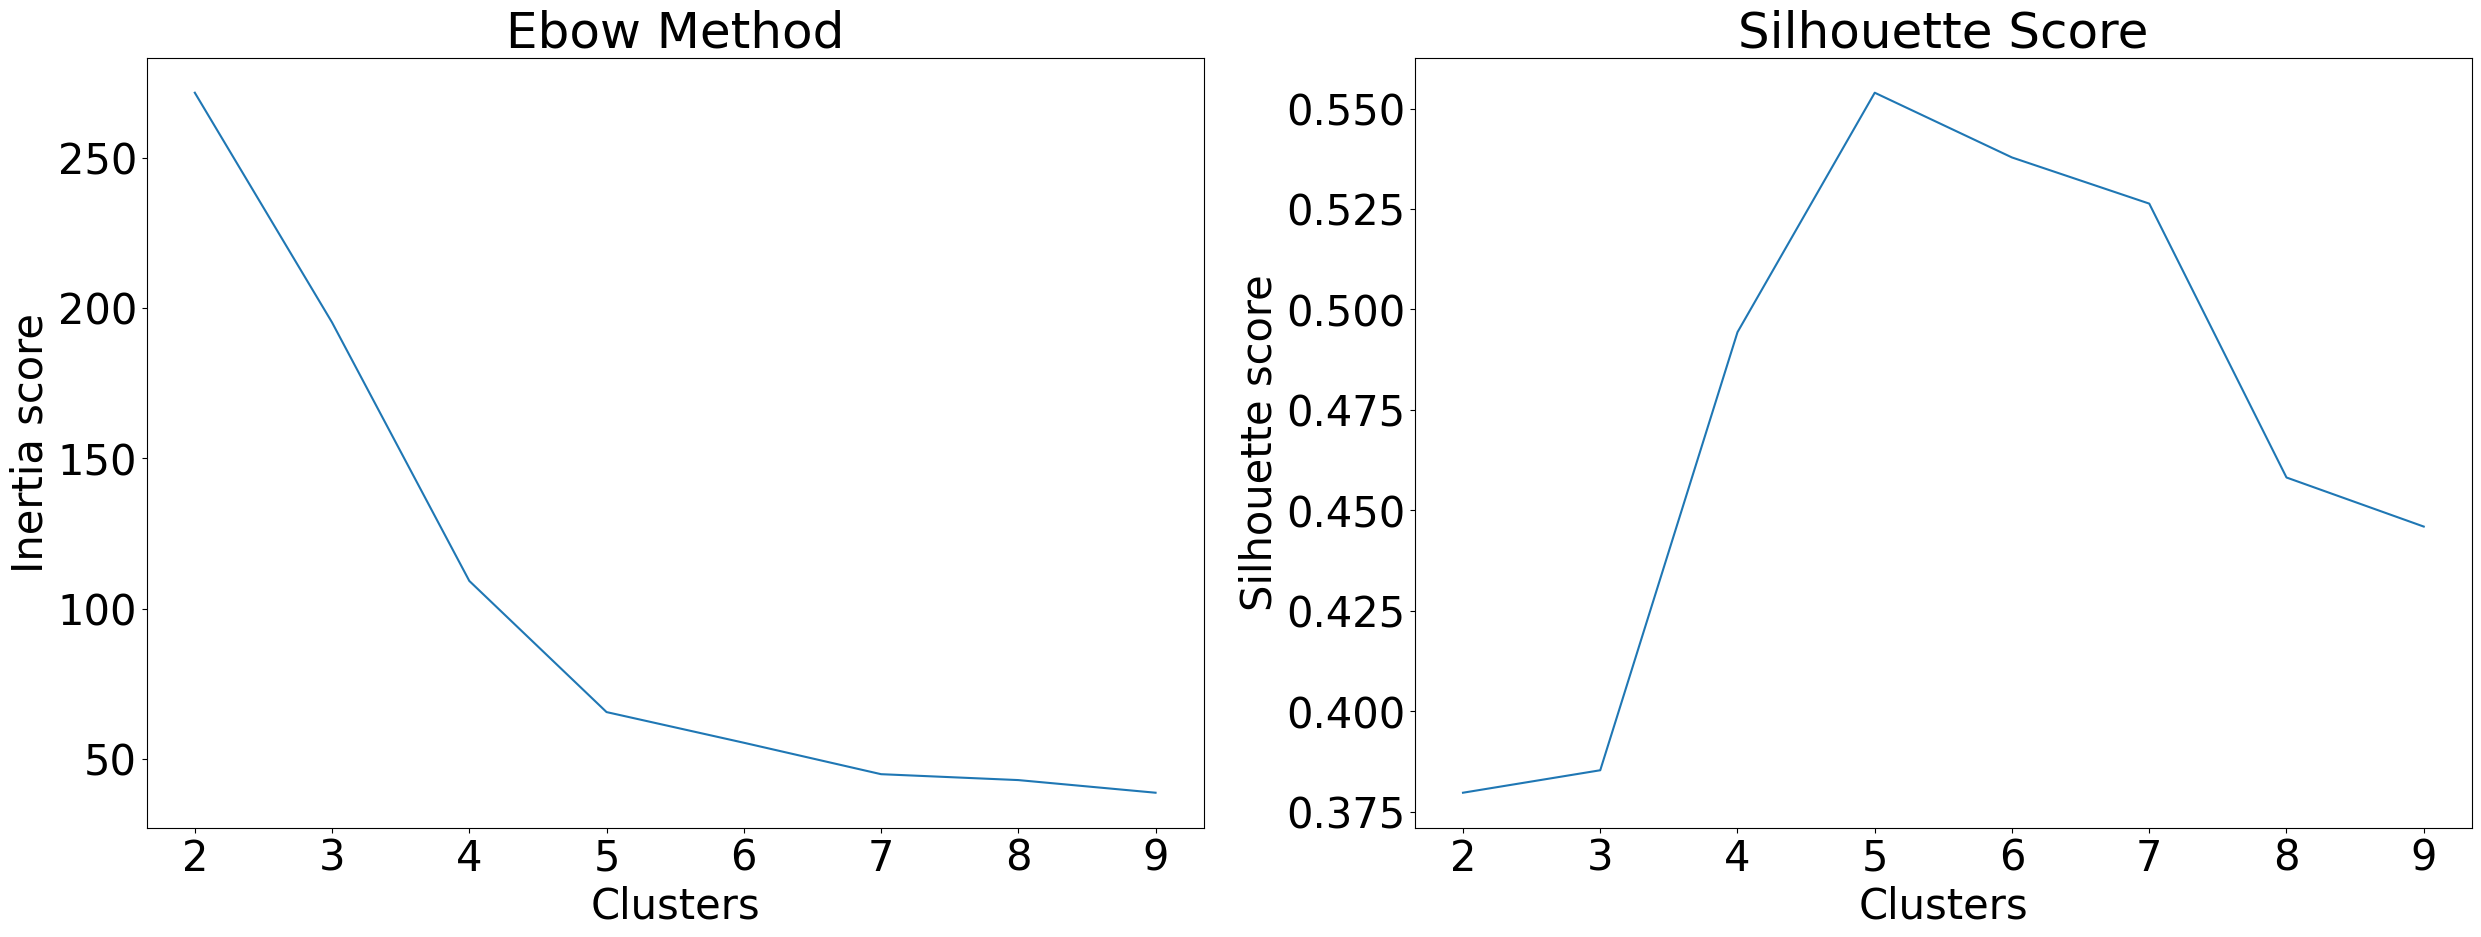

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(30, 10))
axes[0].plot(range(2, 10), scores['inertia'])
axes[0].set_title('Ebow Method')
axes[0].set_xlabel('Clusters')
axes[0].set_ylabel('Inertia score')
axes[1].plot(range(2, 10), scores['silhouette'])
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Clusters')
axes[1].set_ylabel('Silhouette score')
plt.show()

## NPL

In [2]:
df = pd.read_csv('data/synthetic_train.csv')
df.head(n=2)

,sentence,sentiment,topic
0,Đội ngũ bảo trì quá thưa thớt dẫn đến không đả...,negative,facility
1,The university's musical and artistic faciliti...,neutral,facility


In [5]:
tokenize(df.loc[0, 'sentence'])

'Đội_ngũ bảo_trì quá thưa_thớt dẫn đến không đảm_bảo được chất_lượng sửa_chữa thiết_bị .'

In [18]:
df['sentence_tok'] = df['sentence'].map(tokenize)
df.head(n=2)

,sentence,sentiment,topic,sentence_tok
0,Đội ngũ bảo trì quá thưa thớt dẫn đến không đả...,negative,facility,Đội_ngũ bảo_trì quá thưa_thớt dẫn đến không đả...
1,The university's musical and artistic faciliti...,neutral,facility,The_university ' s musical and artistic facili...


In [19]:
sents = df['sentiment'].value_counts()

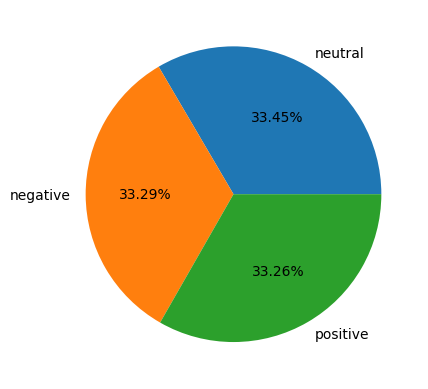

In [21]:
plt.pie(sents, labels=sents.index, autopct='%.2f%%')
plt.show()

In [22]:
df_test = pd.read_csv('data/synthetic_val.csv')
df_test.head(n=2)

,sentence,sentiment,topic
0,Chất lượng vật chất kém.,negative,facility
1,"Phần mềm học tập quá khó sử dụng, khiến sinh v...",negative,facility


In [23]:
df_test['sentence_tok'] = df_test['sentence'].map(tokenize)

In [24]:
df_stopwords = pd.read_csv('data/vietnamese-stopwords-dash.txt', names=['World'])
df_stopwords.head(n=2)

,World
0,a_lô
1,a_ha


In [25]:
count = CountVectorizer()
X = count.fit_transform(df['sentence_tok'])
y = df['sentiment']
X_test = count.transform(df_test['sentence_tok'])
y_test = df_test['sentiment']

In [27]:
X.shape, y.shape, X_test.shape, y_test.shape

((8144, 3600), (8144,), (2036, 3600), (2036,))

In [28]:
df_stopwords['World'].values

array(['a_lô', 'a_ha', 'ai', ..., 'ừ_ào', 'ừ_ừ', 'ử'],
      shape=(1942,), dtype=object)

In [29]:
count = CountVectorizer(stop_words=df_stopwords['World'].values.tolist())
X = count.fit_transform(df['sentence_tok'])
y = df['sentiment']
X_test = count.transform(df_test['sentence_tok'])
y_test = df_test['sentiment']

In [30]:
X.shape, y.shape, X_test.shape, y_test.shape

((8144, 3245), (8144,), (2036, 3245), (2036,))

### AI => ML (machine learning) (text, numberic, image), Phan tich du lieu, NLP (xu ly ngon ngu tu nhien) (text), Deep learning, Computer vision (Image)

In [31]:
mnb = MultinomialNB()
mnb.fit(X,y)
mnb.score(X, y), mnb.score(X_test, y_test)

(0.6987966601178782, 0.611984282907662)

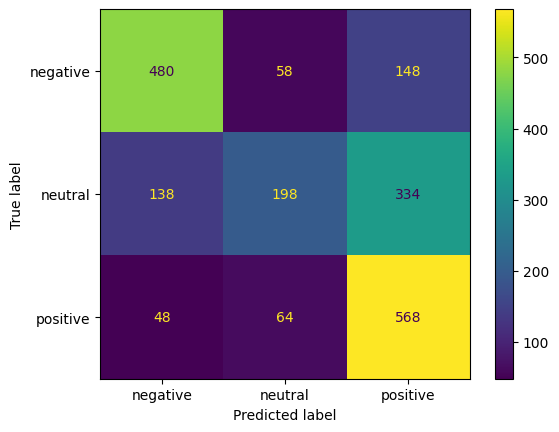

In [32]:
ConfusionMatrixDisplay.from_estimator(estimator=mnb,  X = X_test, y = y_test)
plt.show()

In [39]:
bin = LabelBinarizer()
y_score = mnb.predict_proba(X_test)
y_true = bin.fit_transform(y_test)

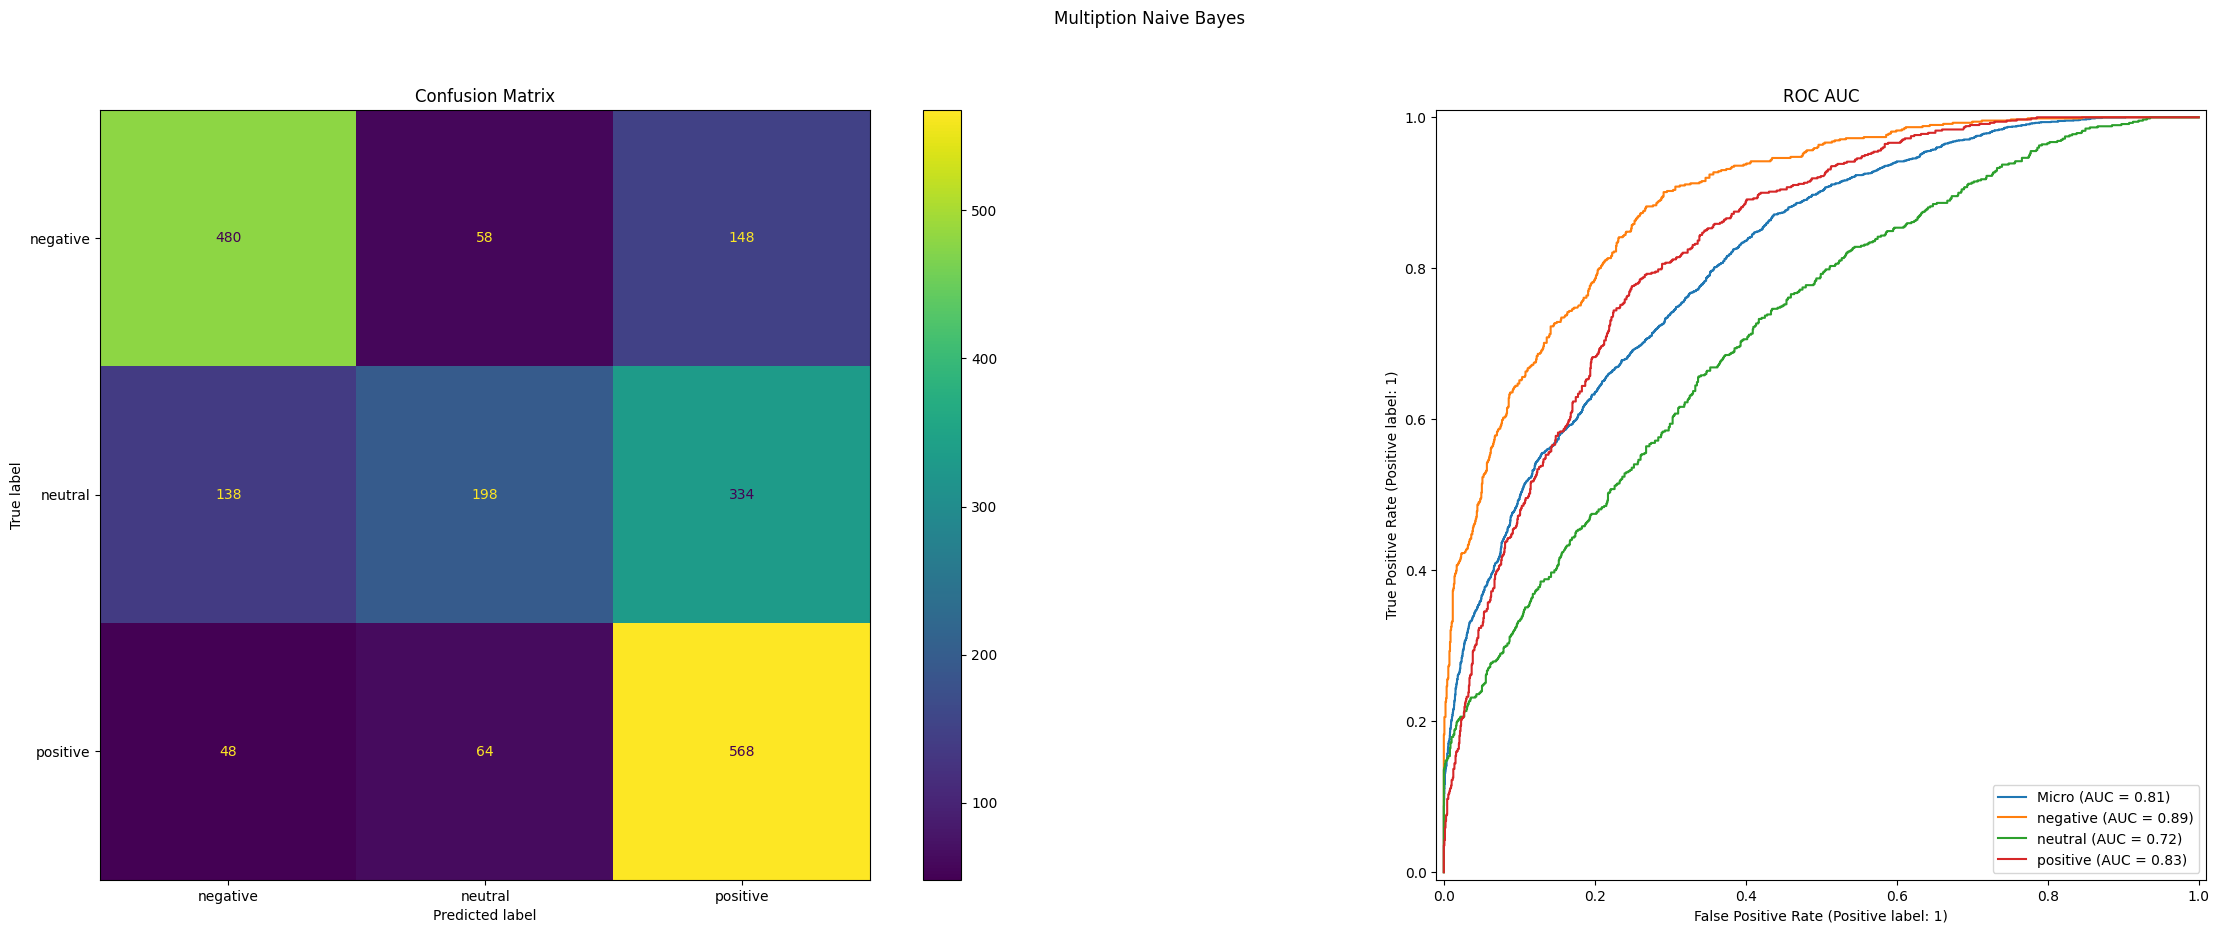

In [42]:
fig, axes = plt.subplots(ncols=2, figsize = (30, 10))
ConfusionMatrixDisplay.from_estimator(estimator=mnb, X = X_test, y = y_test, ax=axes[0])
RocCurveDisplay.from_predictions(y_true.ravel(), y_score.ravel(), name = 'Micro', ax=axes[1])
for i, name in enumerate(sorted(df['sentiment'].unique())):
    RocCurveDisplay.from_predictions(y_true[:, i], y_score[:, i], name = name, ax = axes[1])
axes[0].set_title('Confusion Matrix')
axes[1].set_title('ROC AUC')
plt.suptitle('Multiption Naive Bayes')
plt.show()

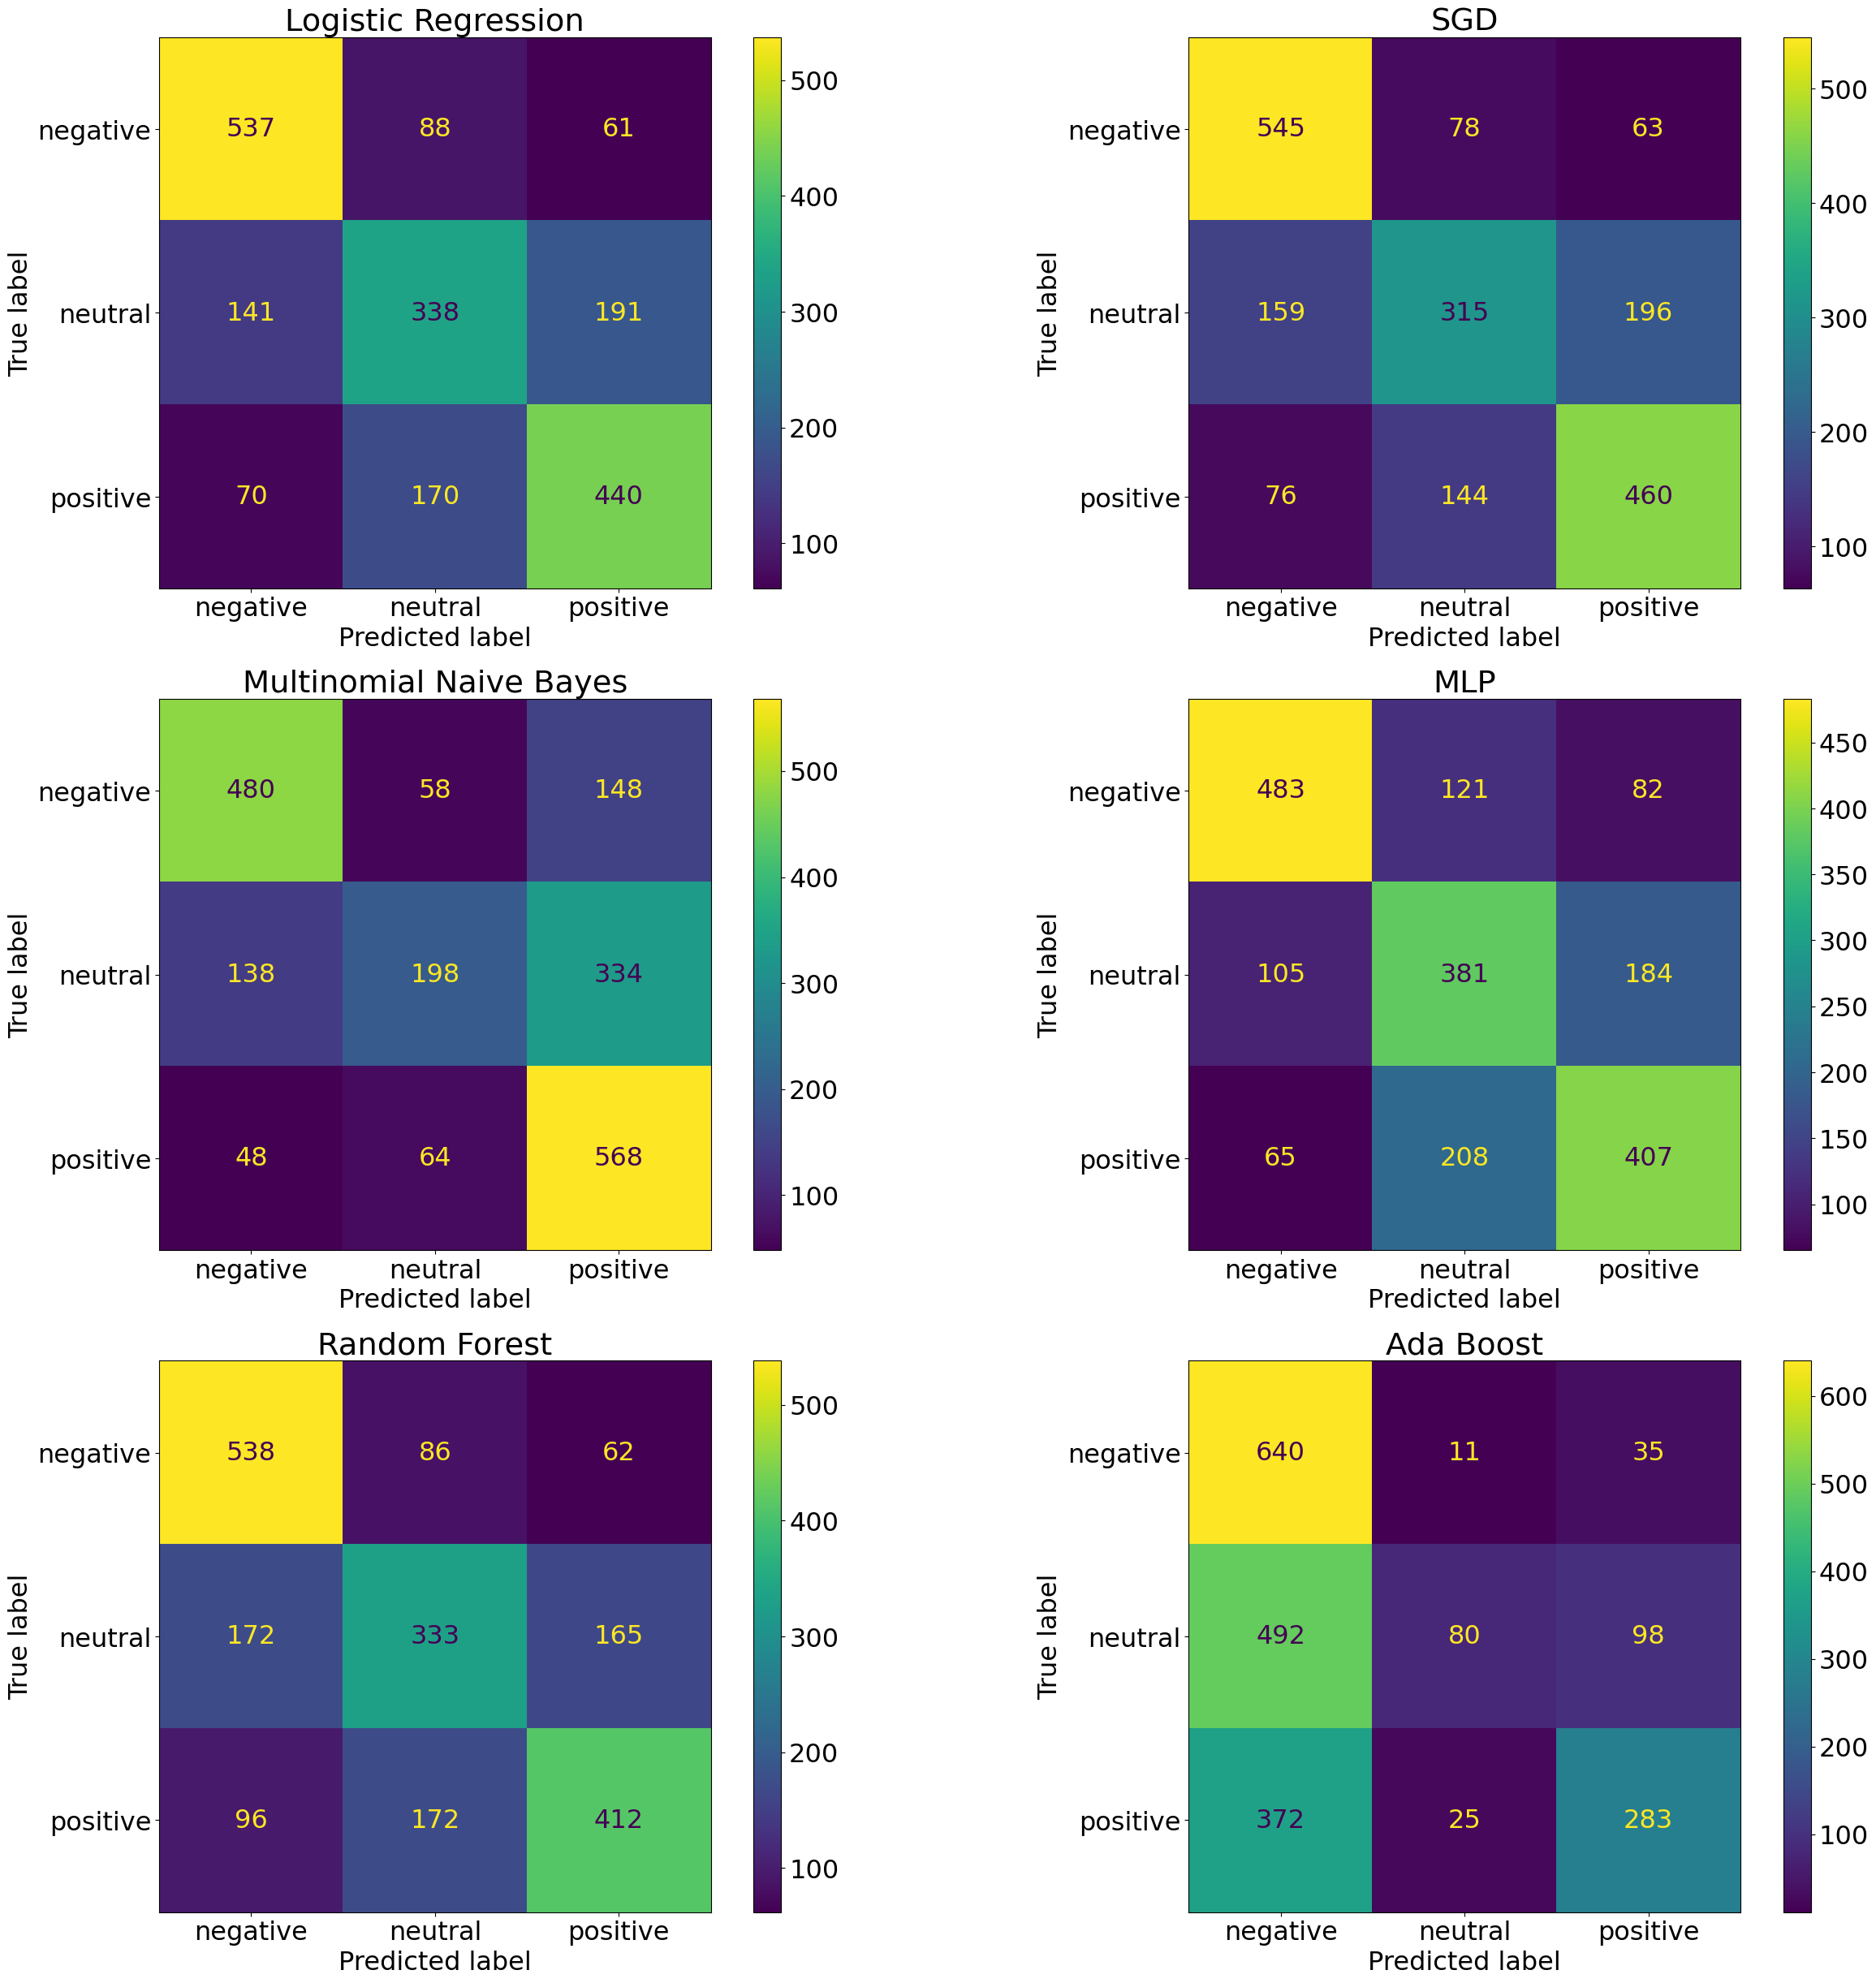

In [43]:
models = {
    "Logistic Regression": LogisticRegression(),
    "SGD": SGDClassifier(loss='log_loss'),
    "Multinomial Naive Bayes": MultinomialNB(),
    "MLP": MLPClassifier(max_iter=5000),
    "Random Forest": RandomForestClassifier(),
    "Ada Boost": AdaBoostClassifier(),
}
plt.rcParams['font.size'] = 23
fig, axes = plt.subplots(nrows=3, ncols = 2, figsize = (30, 30))
axes = axes.flatten()
for i, name in enumerate(models):
    models[name].fit(X, y)
    ConfusionMatrixDisplay.from_estimator(estimator=models[name], X = X_test, y = y_test, ax = axes[i])
    axes[i].set_title(name)
plt.show()

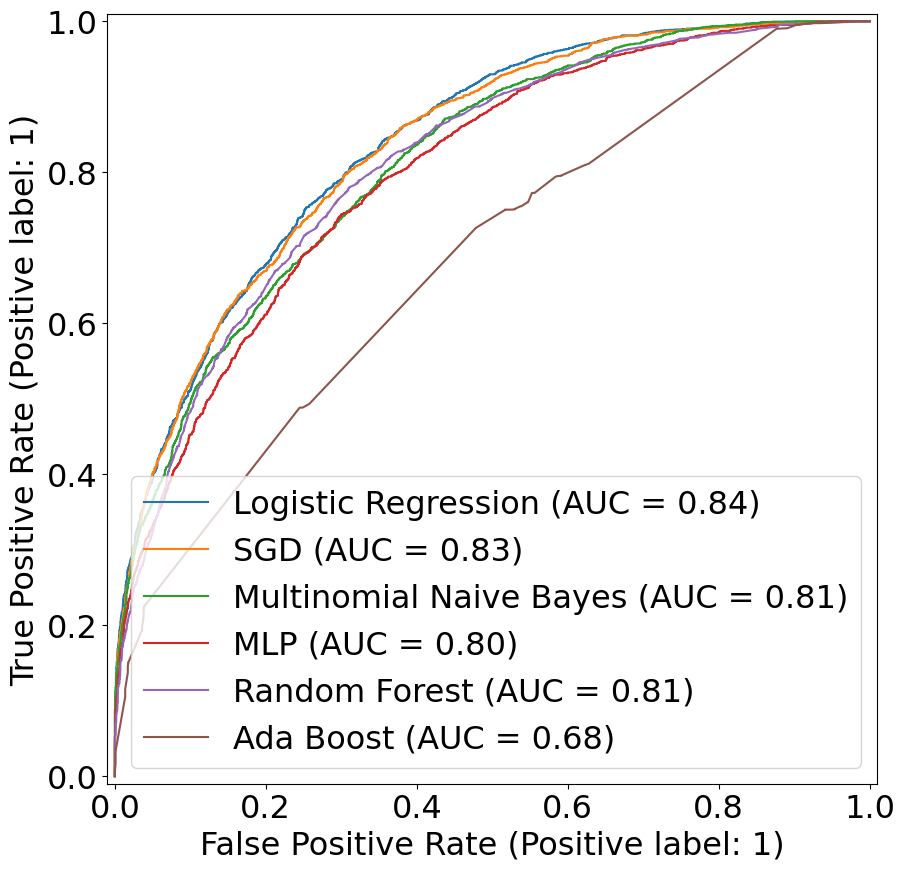

In [44]:
fig, ax = plt.subplots(figsize = (30, 10))
axes = axes.flatten()
binarizer = LabelBinarizer()
y_true = binarizer.fit_transform(y_test)
for i, name in enumerate(models):
    models[name].fit(X, y)
    y_score = models[name].predict_proba(X_test)
    RocCurveDisplay.from_predictions(y_true.ravel(), y_score.ravel(), ax = ax, name = name)
plt.show()